In [1]:
# --------------------------------------------
# a. Read Dataset and create Spark DataFrame -
# --------------------------------------------

spark_df = spark.read.table('FraudDetection.dbo.silver_data_for_MLmodel') #.select(features)

StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 3, Finished, Available, Finished, False)

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Convert Spark → Pandas if needed
df = spark_df.toPandas()

# -------------------------
# Target
# -------------------------
y = df["isFraud"]

# -------------------------
# Categorical
# -------------------------
cat_cols = ["type", "orig_name_type", "dest_name_type"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# -------------------------
# Numeric
# -------------------------
num_cols = [c for c in df.columns if c not in cat_cols + ["isFraud"]]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# -------------------------
# Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["isFraud"]),
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 5, Finished, Available, Finished, False)

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FraudDataset(X_train, y_train)
test_ds = FraudDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512)

StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 6, Finished, Available, Finished, False)

In [4]:
import torch.nn as nn

class FraudNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = FraudNN(input_dim=X_train.shape[1])


StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 7, Finished, Available, Finished, False)

In [5]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

pos_weight = torch.tensor(weights[1], dtype=torch.float32)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 8, Finished, Available, Finished, False)

In [6]:
for epoch in range(100):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        preds = model(X_batch).squeeze()
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 9, Finished, Available, Finished, False)

Epoch 1, Loss: 123.5146
Epoch 2, Loss: 120.6161
Epoch 3, Loss: 120.1854
Epoch 4, Loss: 119.9774
Epoch 5, Loss: 119.8770
Epoch 6, Loss: 119.7313
Epoch 7, Loss: 119.7722
Epoch 8, Loss: 119.5354
Epoch 9, Loss: 119.6052
Epoch 10, Loss: 119.4322
Epoch 11, Loss: 119.4088
Epoch 12, Loss: 119.4510
Epoch 13, Loss: 119.4166
Epoch 14, Loss: 119.3872
Epoch 15, Loss: 119.3916
Epoch 16, Loss: 119.3424
Epoch 17, Loss: 119.4106
Epoch 18, Loss: 119.3821
Epoch 19, Loss: 119.3105
Epoch 20, Loss: 119.3068
Epoch 21, Loss: 119.2599
Epoch 22, Loss: 119.2729
Epoch 23, Loss: 119.3432
Epoch 24, Loss: 119.2827
Epoch 25, Loss: 119.2885
Epoch 26, Loss: 119.2698
Epoch 27, Loss: 119.2140
Epoch 28, Loss: 119.2288
Epoch 29, Loss: 119.2512
Epoch 30, Loss: 119.1794
Epoch 31, Loss: 119.2078
Epoch 32, Loss: 119.1079
Epoch 33, Loss: 119.1210
Epoch 34, Loss: 119.1134
Epoch 35, Loss: 119.1859
Epoch 36, Loss: 119.0213
Epoch 37, Loss: 119.0727
Epoch 38, Loss: 119.0819
Epoch 39, Loss: 119.0659
Epoch 40, Loss: 118.9877
Epoch 41,

StatementMeta(, cc50edcd-5602-49c9-9512-7fb0a8badbfa, 10, Finished, Available, Finished, False)

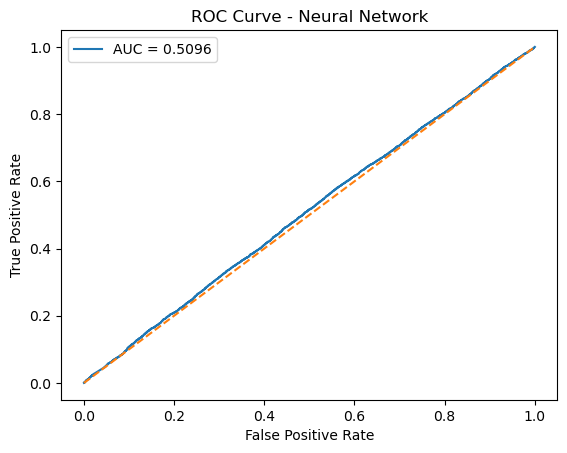

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch).squeeze()
        y_true.extend(y_batch.numpy())
        y_scores.extend(preds.numpy())

# ROC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.show()